In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity


In [3]:
df = pd.read_csv("spotify dataset.csv")
df.head()


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [4]:
# Dataset info
df.info()

# Check missing values
df.isnull().sum()

# Drop duplicates
df.drop_duplicates(inplace=True)

# Convert release date to year
df['track_album_release_date'] = pd.to_datetime(
    df['track_album_release_date'], errors='coerce'
)
df['release_year'] = df['track_album_release_date'].dt.year


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

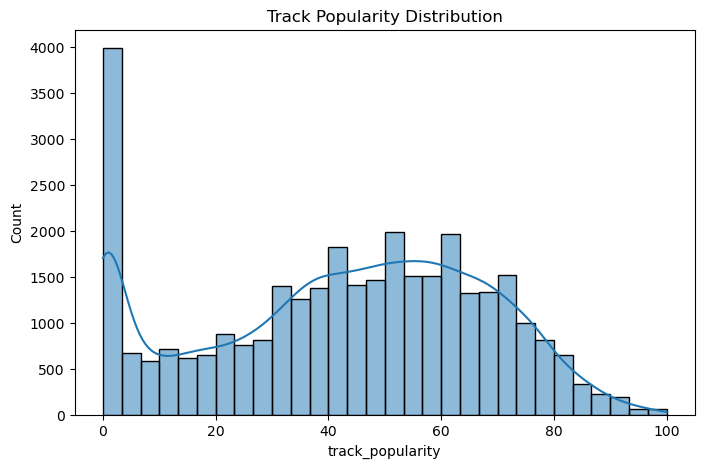

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['track_popularity'], bins=30, kde=True)
plt.title("Track Popularity Distribution")
plt.show()


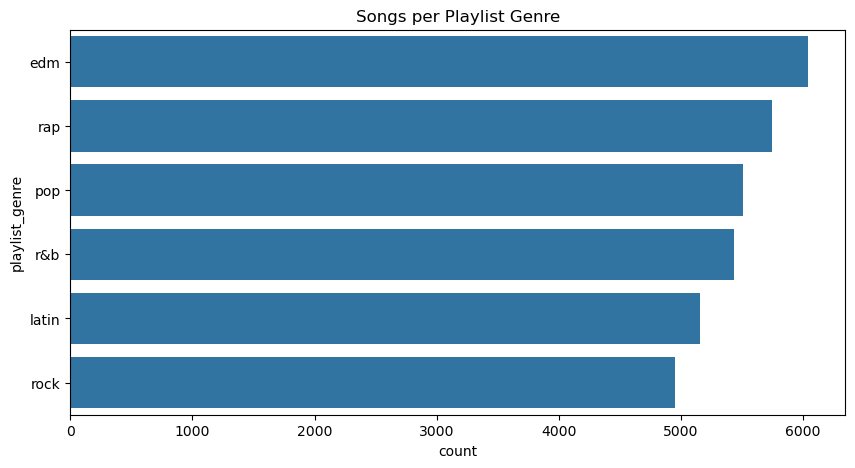

In [6]:
plt.figure(figsize=(10,5))
sns.countplot(y=df['playlist_genre'], order=df['playlist_genre'].value_counts().index)
plt.title("Songs per Playlist Genre")
plt.show()


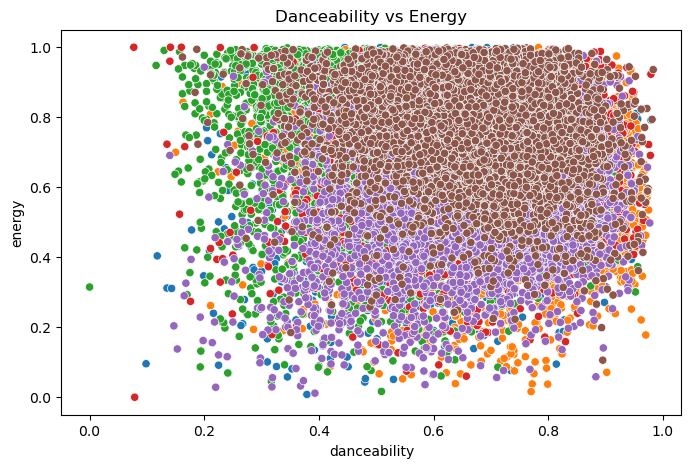

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='danceability', y='energy', hue='playlist_genre', data=df, legend=False)
plt.title("Danceability vs Energy")
plt.show()


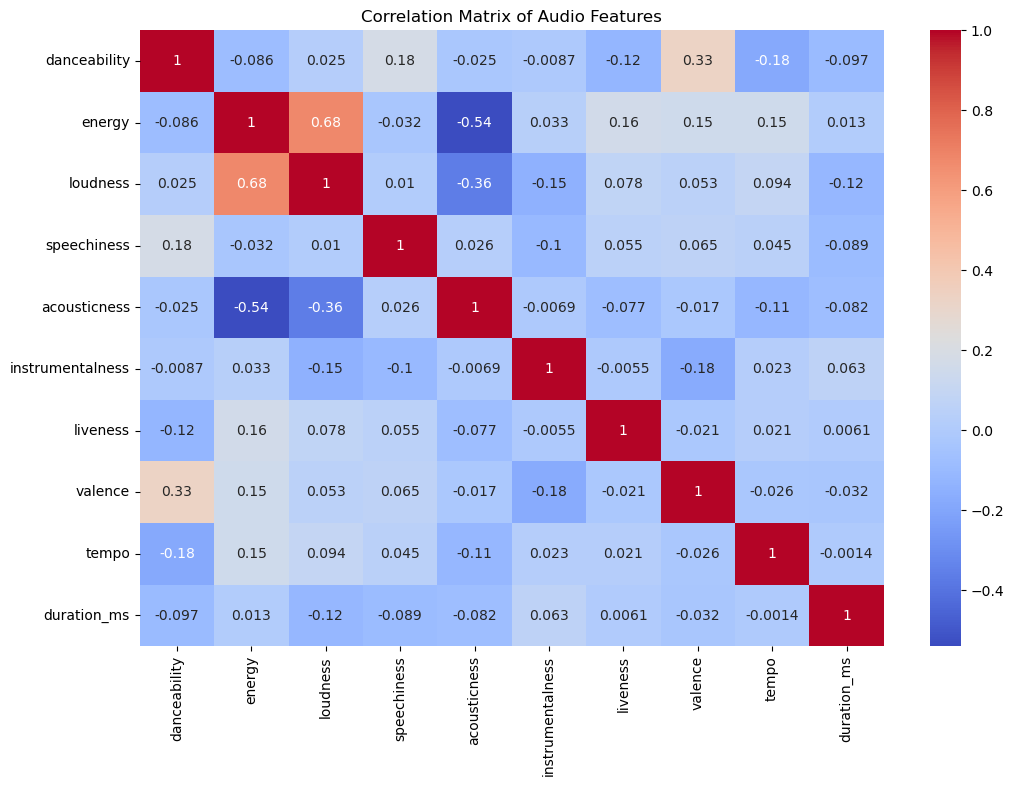

In [8]:
audio_features = [
    'danceability','energy','loudness','speechiness',
    'acousticness','instrumentalness','liveness',
    'valence','tempo','duration_ms'
]

plt.figure(figsize=(12,8))
sns.heatmap(df[audio_features].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Audio Features")
plt.show()


In [9]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[audio_features])


C:\Users\sanja\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\sanja\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\sanja\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sanja\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

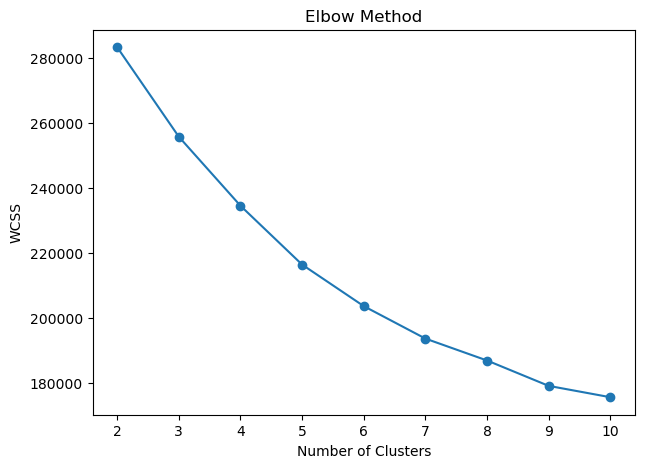

In [10]:
wcss = []
for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(2,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


In [11]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)


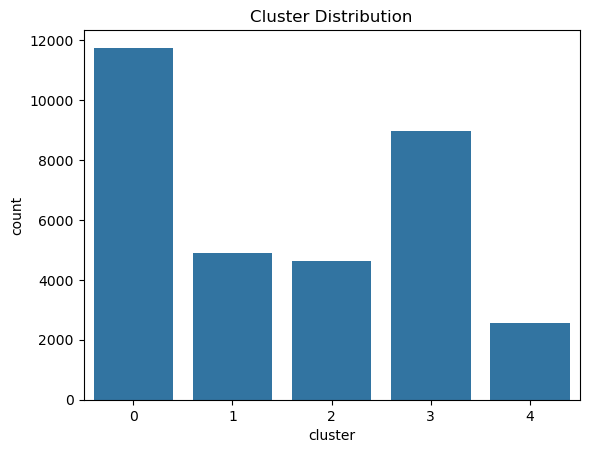

In [12]:
sns.countplot(x='cluster', data=df)
plt.title("Cluster Distribution")
plt.show()


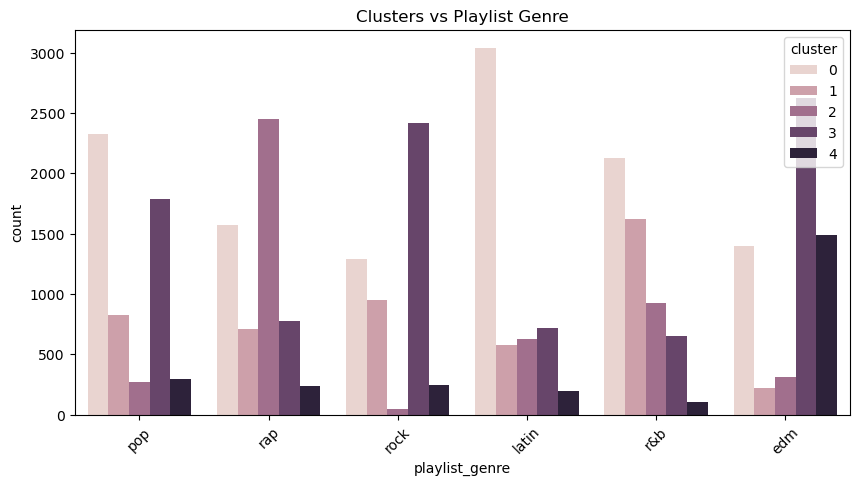

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(x='playlist_genre', hue='cluster', data=df)
plt.xticks(rotation=45)
plt.title("Clusters vs Playlist Genre")
plt.show()


C:\Users\sanja\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


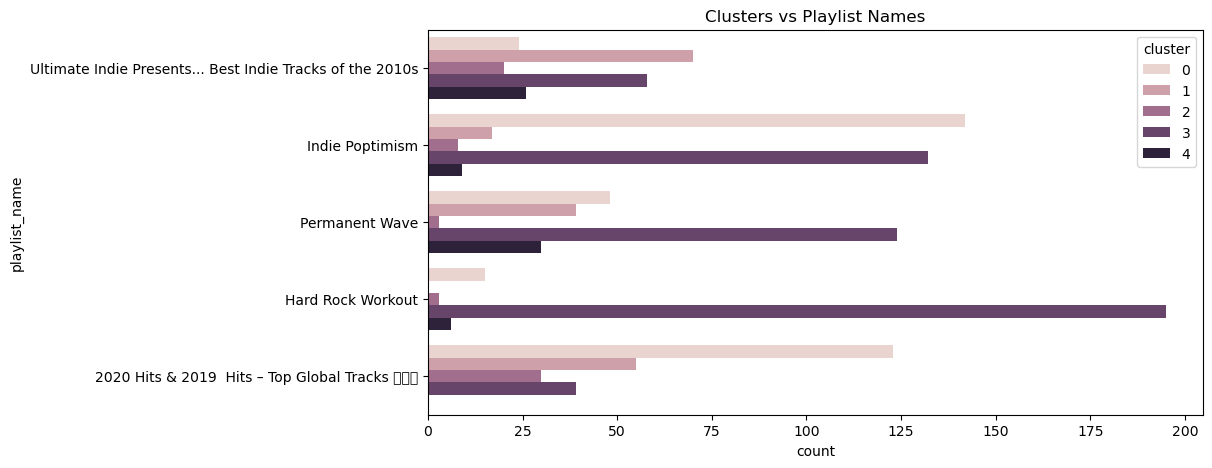

In [14]:
top_playlists = df['playlist_name'].value_counts().head(5).index
subset = df[df['playlist_name'].isin(top_playlists)]

plt.figure(figsize=(10,5))
sns.countplot(y='playlist_name', hue='cluster', data=subset)
plt.title("Clusters vs Playlist Names")
plt.show()


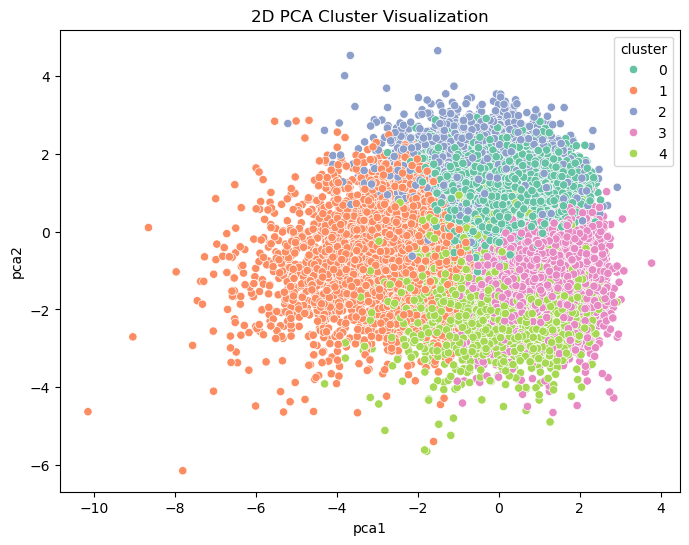

In [15]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

df['pca1'] = pca_result[:,0]
df['pca2'] = pca_result[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(x='pca1', y='pca2', hue='cluster', data=df, palette='Set2')
plt.title("2D PCA Cluster Visualization")
plt.show()


In [16]:
similarity = cosine_similarity(scaled_features)


In [17]:
def recommend_songs(song_name, n=5):
    if song_name not in df['track_name'].values:
        return "Song not found in dataset"
    
    idx = df[df['track_name'] == song_name].index[0]
    sim_scores = list(enumerate(similarity[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    top_songs = sim_scores[1:n+1]
    recommendations = df.iloc[[i[0] for i in top_songs]][
        ['track_name','track_artist','playlist_genre']
    ]
    return recommendations


In [25]:
from IPython.display import display
import ipywidgets as widgets
songs_dropdown = widgets.Dropdown(
    options=sorted(df['track_name'].dropna().astype(str).unique()),
    description='Pick a Song : ',
    style={'description_width':'initial'},
    layout=widgets.Layout(width = '50%')
)
recommend_button=widgets.Button(description= 'Get Recommendations')
output=widgets.Output()

def on_button_clicked(b):
    output.clear_output()
    with output:
        selected_song=songs_dropdown.value
        recommended_song = recommend_songs(selected_song,5)
        print(f"Recommended movies for '{selected_song}':\n")
        display(recommended_song)
recommend_button.on_click(on_button_clicked)
display(songs_dropdown,recommend_button,output)

Dropdown(description='Pick a Song : ', layout=Layout(width='50%'), options=('"I TRIED FOR YEARS... NOBODY LIST…

Button(description='Get Recommendations', style=ButtonStyle())

Output()